In [1]:
import pandas as pd
import numpy as np
import statsmodels.api as sm
import statsmodels.formula.api as smf
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# Source: ProPublica GitHub Repository
raw_data = pd.read_csv("compas-scores-two-years.csv")
print(f"Initial rows: {len(raw_data)}")

Initial rows: 7214


In [2]:
# Filtering criteria from the original ProPublica methodology
df = raw_data[
    (raw_data['days_b_screening_arrest'] <= 30) & 
    (raw_data['days_b_screening_arrest'] >= -30) & 
    (raw_data['is_recid'] != -1) & 
    (raw_data['c_charge_degree'] != "O") & 
    (raw_data['score_text'] != 'N/A')
].copy()

# Focus on African-American and Caucasian for primary bias analysis 
df = df[df['race'].isin(['African-American', 'Caucasian'])]

# Create a binary target for high/medium risk vs low risk
df['is_high_risk'] = (df['score_text'] != 'Low').astype(int)

print(f"Rows after filtering: {len(df)}")

Rows after filtering: 5278


In [3]:
# Replicating the logistic regression model from the methodology
# Dependent variable: is_high_risk (Score >= 5)
# Controls: sex, age_cat, race, priors_count, c_charge_degree, two_year_recid
formula = "is_high_risk ~ sex + age_cat + race + priors_count + c_charge_degree + two_year_recid"
model = smf.logit(formula, data=df).fit()

print(model.summary())

# Calculate Odds Ratios for interpretation [cite: 34]
odds_ratios = np.exp(model.params)
print("\n--- Odds Ratios ---")
print(odds_ratios)

Optimization terminated successfully.
         Current function value: 0.513335
         Iterations 6
                           Logit Regression Results                           
Dep. Variable:           is_high_risk   No. Observations:                 5278
Model:                          Logit   Df Residuals:                     5270
Method:                           MLE   Df Model:                            7
Date:                Sun, 12 Apr 2026   Pseudo R-squ.:                  0.2584
Time:                        11:15:27   Log-Likelihood:                -2709.4
converged:                       True   LL-Null:                       -3653.5
Covariance Type:            nonrobust   LLR p-value:                     0.000
                                 coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------------------
Intercept                     -0.7415      0.094     -7.884      0.000      

In [4]:
def get_confusion_metrics(data, race_label):
    subset = data[data['race'] == race_label]
    y_true = subset['two_year_recid']
    y_pred = subset['is_high_risk']
    
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    
    fpr = fp / (fp + tn) # False Positive Rate
    fnr = fn / (fn + tp) # False Negative Rate
    
    return fpr, fnr

aa_fpr, aa_fnr = get_confusion_metrics(df, 'African-American')
c_fpr, c_fnr = get_confusion_metrics(df, 'Caucasian')

print(f"African-American -> FPR: {aa_fpr:.2%}, FNR: {aa_fnr:.2%}")
print(f"Caucasian        -> FPR: {c_fpr:.2%}, FNR: {c_fnr:.2%}")

African-American -> FPR: 42.34%, FNR: 28.48%
Caucasian        -> FPR: 22.01%, FNR: 49.64%


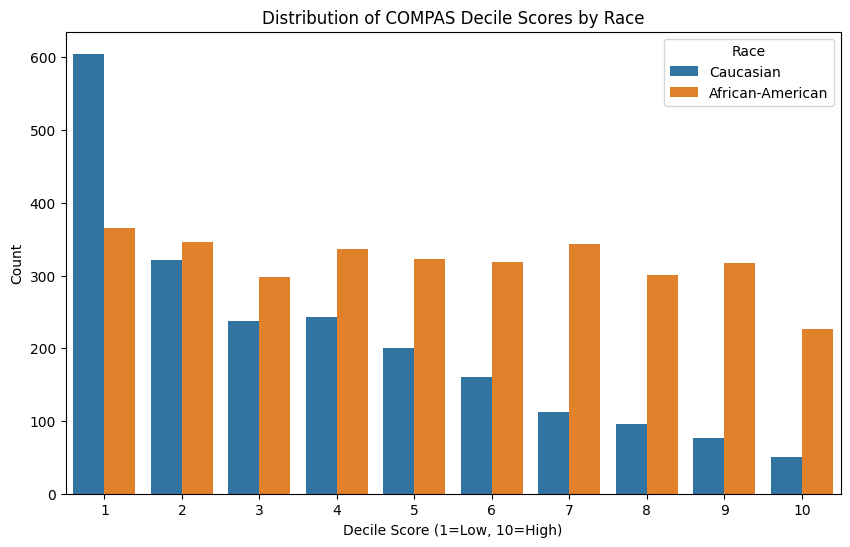

In [5]:
plt.figure(figsize=(10, 6))
sns.countplot(x='decile_score', hue='race', data=df)
plt.title("Distribution of COMPAS Decile Scores by Race")
plt.xlabel("Decile Score (1=Low, 10=High)")
plt.ylabel("Count")
plt.legend(title='Race')
plt.show()